In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# STEP 1: Load Data & Define Features

df = pd.read_csv('/content/drive/MyDrive/Spring 2026/Machine Learning For Cities/MLC Final Project/data/V2merged_data_clean.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# feautre definitions
feature_cols = [
    'pluto_mean_yearbuilt', 'pluto_mean_effective_year', 'pluto_mean_builtfar',
    'pluto_bldgarea_per_unit', 'pluto_resarea_per_unit',
    'pluto_avg_lotarea', 'pluto_commercial_share', 'pluto_pct_residential',
    'pluto_pct_historic', 'pluto_pct_landmark',
    'canopy_treecanopy', 'canopy_temp_diff',
    'subway_05mi', 'bus_025mi',
    'median_income', 'pct_nonwhite', 'pct_renter', 'avg_hh_size',
    'pct_rent_burdened', 'Total Households']

socio_cols = [
    'median_income', 'pct_nonwhite', 'pct_renter',
    'avg_hh_size', 'pct_rent_burdened', 'Total Households'
]

# target cleaning
# drop rows with missing or zero energy burden
df = df[df['Energy Burden (% income)'].notna()].copy()
df = df[df['Energy Burden (% income)'] > 0].copy()
y = df['Energy Burden (% income)'].reset_index(drop=True)

#feature cleaning (Values like -66666666)
df_clean = df[feature_cols].copy()
for col in feature_cols:
    if df_clean[col].dtype != 'object':
        df_clean[col] = df_clean[col].where(df_clean[col] > -1000, np.nan)

#feature Matrix (X) and Impute
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(df_clean), columns=feature_cols)

#socio-only Feature Matrix (X_socio)
X_socio = X[socio_cols].copy()

print(f'Ready for modeling. Final rows: {len(y)}')

Loaded: 2,212 rows x 37 columns
Ready for modeling. Final rows: 2212


In [ ]:
# STEP 2: Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)

X_socio_train = X_train[socio_cols].copy()
X_socio_test  = X_test[socio_cols].copy()

print(f'Training set: {X_train.shape[0]:,} tracts')
print(f'Test set:     {X_test.shape[0]:,} tracts')
print(f'Train burden mean: {y_train.mean():.3f}')
print(f'Test burden mean:  {y_test.mean():.3f}')

Training set: 1,769 tracts
Test set:     443 tracts
Train burden mean: 2.782
Test burden mean:  2.871


In [ ]:
# STEP 3: Baseline RF Comparison

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Spec A: Baseline
rf_baseline = RandomForestRegressor(n_estimators=200, random_state=42)

# Spec B: Optimized for Generalization
rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

# Function
def evaluate_model(model, X_data, y_data, label):
    scores = cross_val_score(model, X_data, y_data, cv=kf, scoring='r2')
    print(f"{label} R²: {scores.mean():.3f} (+/- {scores.std():.3f})")

print("\n--- BASELINE MODEL COMPARISON ---")
evaluate_model(rf_baseline, X_train, y_train, "Full RF Model (Baseline Specs)")
evaluate_model(rf_tuned, X_train, y_train, "Full RF Model (Tuned Specs)")
evaluate_model(rf_tuned, X_socio_train, y_train, "Socio-Only RF Model (Tuned Specs)")


--- BASELINE MODEL COMPARISON ---
Full RF Model (Baseline Specs) R²: 0.576 (+/- 0.050)
Full RF Model (Tuned Specs) R²: 0.579 (+/- 0.030)
Socio-Only RF Model (Tuned Specs) R²: 0.527 (+/- 0.031)


In [ ]:
# Step 4: Three-way CV comparison

# Model definitions
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_ablation = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

# Linear regression baseline (socioeconomic features only, scaled)
rmse_lr = cross_val_score(lr, X_socio_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_lr   = cross_val_score(lr, X_socio_train, y_train, cv=kf, scoring='r2')

# Random Forest full model (all features)
rmse_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_rf   = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')

# Random Forest ablation (socioeconomic features only)
rmse_ab = cross_val_score(rf_ablation, X_socio_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_ab   = cross_val_score(rf_ablation, X_socio_train, y_train, cv=kf, scoring='r2')

print('Model Comparison (5-fold CV on training set)')
print(f'Linear Regression  (socioeconomic only) | RMSE: {(-rmse_lr.mean()):.4f} | R2: {r2_lr.mean():.4f}')
print(f'RF Ablation        (socioeconomic only) | RMSE: {(-rmse_ab.mean()):.4f} | R2: {r2_ab.mean():.4f}')
print(f'RF Full Model      (all features)       | RMSE: {(-rmse_rf.mean()):.4f} | R2: {r2_rf.mean():.4f}')
print()
print(f'Delta R2 (full RF vs ablation RF): {r2_rf.mean() - r2_ab.mean():.4f}')
print('This is the independent contribution of urban form features.')

Model Comparison (5-fold CV on training set)
Linear Regression  (socioeconomic only) | RMSE: 0.9251 | R2: 0.4653
RF Ablation        (socioeconomic only) | RMSE: 0.8723 | R2: 0.5244
RF Full Model      (all features)       | RMSE: 0.8229 | R2: 0.5760

Delta R2 (full RF vs ablation RF): 0.0515
This is the independent contribution of urban form features.


In [ ]:
# Step 5: Run Tuned Random Forest Models

rf_tuned_full = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_tuned_ablation = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Running Tuned Models (this might take a few seconds)...\n")

# Evaluate Tuned Full Model
rmse_tuned_rf = cross_val_score(rf_tuned_full, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_tuned_rf   = cross_val_score(rf_tuned_full, X_train, y_train, cv=kf, scoring='r2')

# Evaluate Tuned Ablation (Socio-only) Model
rmse_tuned_ab = cross_val_score(rf_tuned_ablation, X_socio_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
r2_tuned_ab   = cross_val_score(rf_tuned_ablation, X_socio_train, y_train, cv=kf, scoring='r2')

print('--- TUNED MODEL RESULTS ---')
print(f'Tuned RF Ablation   (socio only) | RMSE: {(-rmse_tuned_ab.mean()):.4f} | R2: {r2_tuned_ab.mean():.4f}')
print(f'Tuned RF Full Model (all feats)  | RMSE: {(-rmse_tuned_rf.mean()):.4f} | R2: {r2_tuned_rf.mean():.4f}')
print()
print(f'Tuned Delta R2 (full vs ablation): {r2_tuned_rf.mean() - r2_tuned_ab.mean():.4f}')

# Compare to baseline 200-tree RF
print("\n--- IMPROVEMENT OVER BASELINE ---")
print(f"Full Model R2 Improvement: {(r2_tuned_rf.mean() - r2_rf.mean()):.4f}")
print("This shows how hyperparameter tuning changed performance relative to the 200-tree baseline.")

Running Tuned Models (this might take a few seconds)...

--- TUNED MODEL RESULTS ---
Tuned RF Ablation   (socio only) | RMSE: 0.8677 | R2: 0.5296
Tuned RF Full Model (all feats)  | RMSE: 0.8183 | R2: 0.5817

Tuned Delta R2 (full vs ablation): 0.0521

--- IMPROVEMENT OVER BASELINE ---
Full Model R2 Improvement: 0.0057
This shows how hyperparameter tuning changed performance relative to the 200-tree baseline.


In [ ]:
# Step 6: RandomizedSearchCV Hyperparameter Tuning

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

# smaller CV
search_kf = KFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=search_kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# FIT ON TRAINING SET
random_search.fit(X_train, y_train)

# best params
best_params = random_search.best_params_
print(f"\nBest Parameters Found: {best_params}")

# Run final 5-fold evaluation with best specs
best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
final_scores = cross_val_score(best_rf, X_train, y_train, cv=kf, scoring='r2')

print(f"Final Optimized R²: {final_scores.mean():.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Found: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
Final Optimized R²: 0.5866


In [ ]:
# Step 7: Final CV Comparison with Best Hyperparameters

# Apply the best parameters to the Socio-Only ablation
rf_tuned_ablation_best = RandomForestRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)

# Evaluate the Ablation model on training set
r2_tuned_ab_best = cross_val_score(rf_tuned_ablation_best, X_socio_train, y_train, cv=kf, scoring='r2')

print("\n=== FINAL COMPARISON ===")
print(f"Tuned Full Model R²:   {final_scores.mean():.4f}")
print(f"Tuned Ablation R²:     {r2_tuned_ab_best.mean():.4f}")
print(f"Delta R² (Urban Form contribution): {final_scores.mean() - r2_tuned_ab_best.mean():.4f}")


=== FINAL COMPARISON ===
Tuned Full Model R²:   0.5866
Tuned Ablation R²:     0.5307
Delta R² (Urban Form contribution): 0.0559


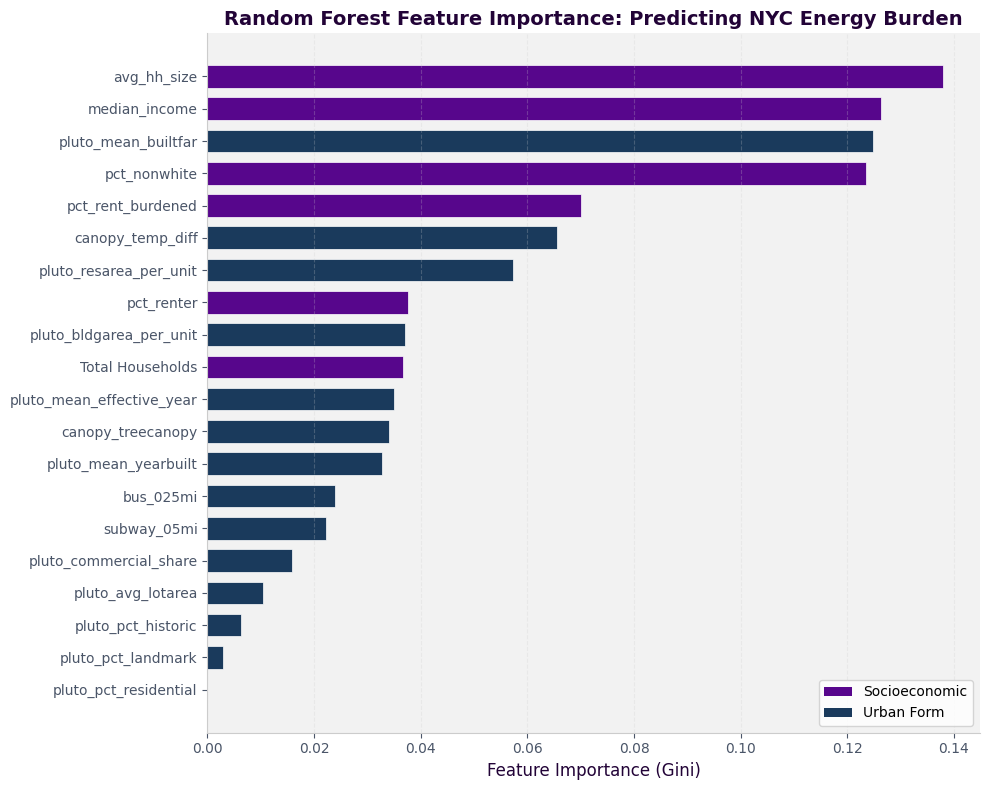


--- TOP 5 URBAN FORM PREDICTORS ---
                      Feature  Importance
2         pluto_mean_builtfar    0.124736
11           canopy_temp_diff    0.065549
4      pluto_resarea_per_unit    0.057210
3     pluto_bldgarea_per_unit    0.037074
1   pluto_mean_effective_year    0.035001


In [ ]:
# Step 8: Feature Importance Analysis

# 1. Fit on full dataset using best params
rf_final = RandomForestRegressor(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X, y)

# 2. Extract importances
importances = rf_final.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=True)

# 3. Plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

# Purple for socioeconomic, navy for urban form
colors = ['#57068C' if f in socio_cols else '#1A3A5C' for f in importance_df['Feature']]

ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors, edgecolor='white', linewidth=0.5, height=0.7)

ax.set_xlabel('Feature Importance (Gini)', fontsize=12, color='#220337')
ax.set_title('Random Forest Feature Importance: Predicting NYC Energy Burden',
             fontsize=14, fontweight='bold', color='#220337')
ax.grid(axis='x', linestyle='--', alpha=0.25, color='#CCCCCC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(colors='#4A5568')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#57068C', label='Socioeconomic'),
    Patch(facecolor='#1A3A5C', label='Urban Form'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.8, edgecolor='#CCCCCC')

plt.tight_layout()
plt.show()

# 4. Top 5 urban form variables
print("\n--- TOP 5 URBAN FORM PREDICTORS ---")
urban_form_only = importance_df[~importance_df['Feature'].isin(socio_cols)]
print(urban_form_only.sort_values(by='Importance', ascending=False).head(5))

Calculating Correlation Matrix...


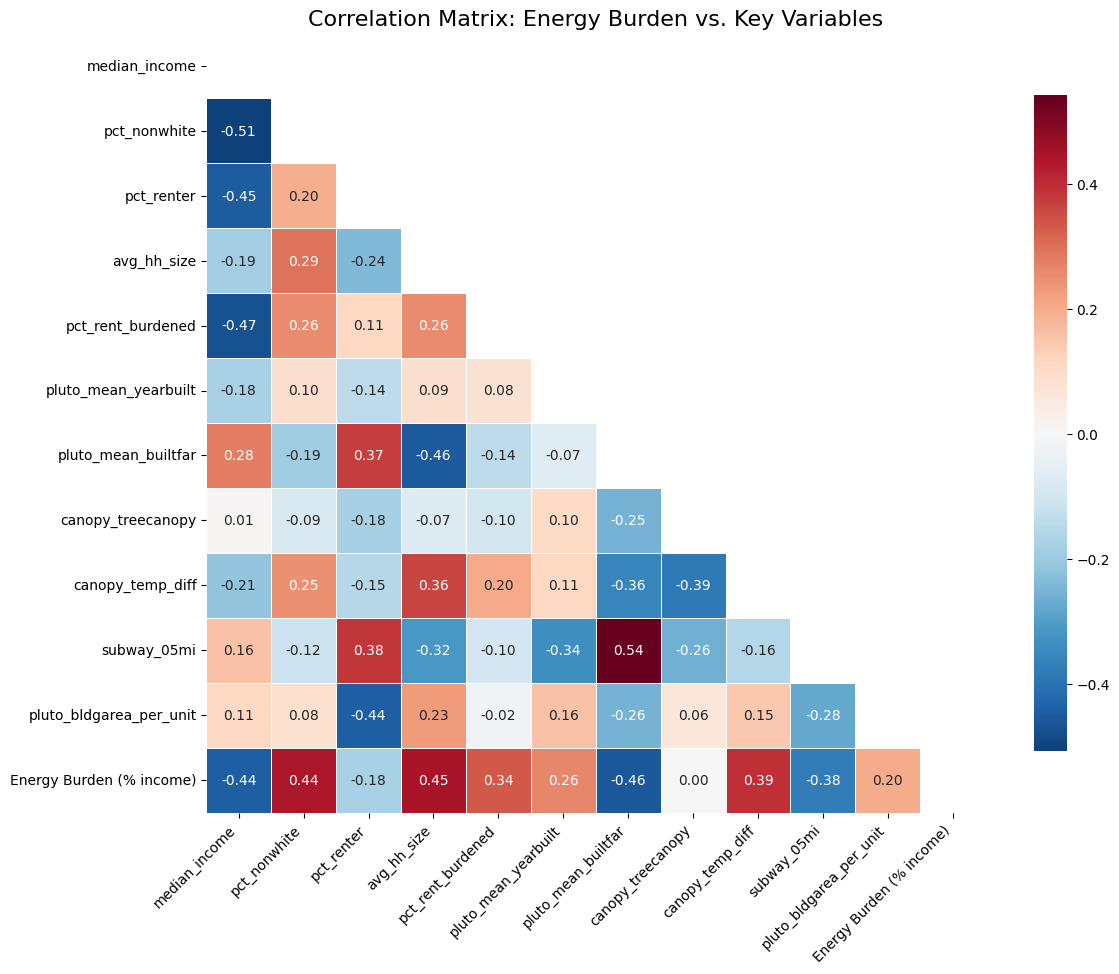

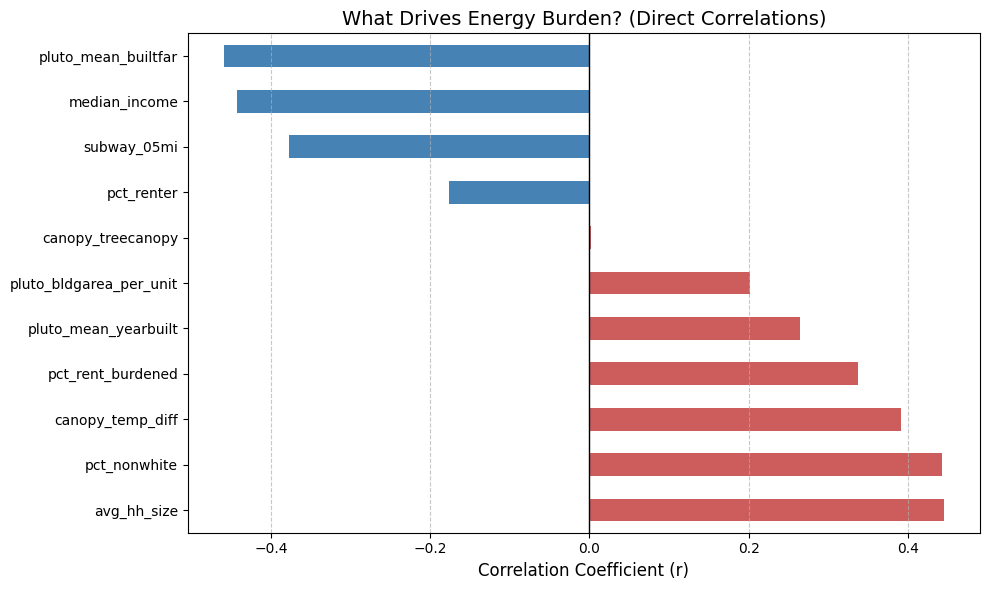


--- TOP CORRELATIONS WITH ENERGY BURDEN ---
avg_hh_size                0.445506
pct_nonwhite               0.443376
canopy_temp_diff           0.391996
pct_rent_burdened          0.337487
pluto_mean_yearbuilt       0.264920
pluto_bldgarea_per_unit    0.201589
canopy_treecanopy          0.001799
pct_renter                -0.177088
subway_05mi               -0.377200
median_income             -0.442972
pluto_mean_builtfar       -0.459291
Name: Energy Burden (% income), dtype: float64


In [ ]:
# Step 9: Correlation Matrix & Target Analysis

print("Calculating Correlation Matrix...")

target_col = 'Energy Burden (% income)'
socio_cols_plot = ['median_income', 'pct_nonwhite', 'pct_renter', 'avg_hh_size', 'pct_rent_burdened']
urban_cols_plot = ['pluto_mean_yearbuilt', 'pluto_mean_builtfar', 'canopy_treecanopy', 'canopy_temp_diff', 'subway_05mi', 'pluto_bldgarea_per_unit']

X_corr = X[socio_cols_plot + urban_cols_plot].copy()
X_corr[target_col] = y.values

corr_subset = X_corr.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(
    corr_subset,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix: Energy Burden vs. Key Variables', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
target_correlations = X_corr.corr()[target_col].sort_values(ascending=False)
target_correlations = target_correlations.drop(target_col)
colors = ['indianred' if x > 0 else 'steelblue' for x in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.title('What Drives Energy Burden? (Direct Correlations)', fontsize=14)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.axvline(x=0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- TOP CORRELATIONS WITH ENERGY BURDEN ---")
print(target_correlations)

In [ ]:
# Step 10: Final Test Set Evaluation

# Fit all three models on training data only
rf_final_test = RandomForestRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
rf_final_test.fit(X_train, y_train)

rf_ablation_final = RandomForestRegressor(**random_search.best_params_, random_state=42, n_jobs=-1)
rf_ablation_final.fit(X_socio_train, y_train)

lr_final = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
lr_final.fit(X_socio_train, y_train)

# Evaluate on test set
def test_metrics(model, X_te, y_te, label):
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    print(f'{label:<40} | RMSE: {rmse:.4f} | R²: {r2:.4f}')

print('=== FINAL TEST SET RESULTS ===')
test_metrics(lr_final,          X_socio_test, y_test, 'Linear Regression (socio only)')
test_metrics(rf_ablation_final, X_socio_test, y_test, 'RF Ablation (socio only)')
test_metrics(rf_final_test,     X_test,       y_test, 'RF Full Model (all features)')

# Urban form contribution on test set
r2_full_test    = r2_score(y_test, rf_final_test.predict(X_test))
r2_ablation_test = r2_score(y_test, rf_ablation_final.predict(X_socio_test))
print(f'\nUrban form contribution (ΔR²): {r2_full_test - r2_ablation_test:.4f}')

# Gap check: CV R² vs Test R²
cv_r2   = final_scores.mean()
test_r2 = r2_full_test
print(f'\nCV R²: {cv_r2:.4f}  |  Test R²: {test_r2:.4f}  |  Gap: {cv_r2 - test_r2:.4f}')

=== FINAL TEST SET RESULTS ===
Linear Regression (socio only)           | RMSE: 0.9410 | R²: 0.4877
RF Ablation (socio only)                 | RMSE: 0.8850 | R²: 0.5468
RF Full Model (all features)             | RMSE: 0.8110 | R²: 0.6194

Urban form contribution (ΔR²): 0.0726

CV R²: 0.5866  |  Test R²: 0.6194  |  Gap: -0.0329


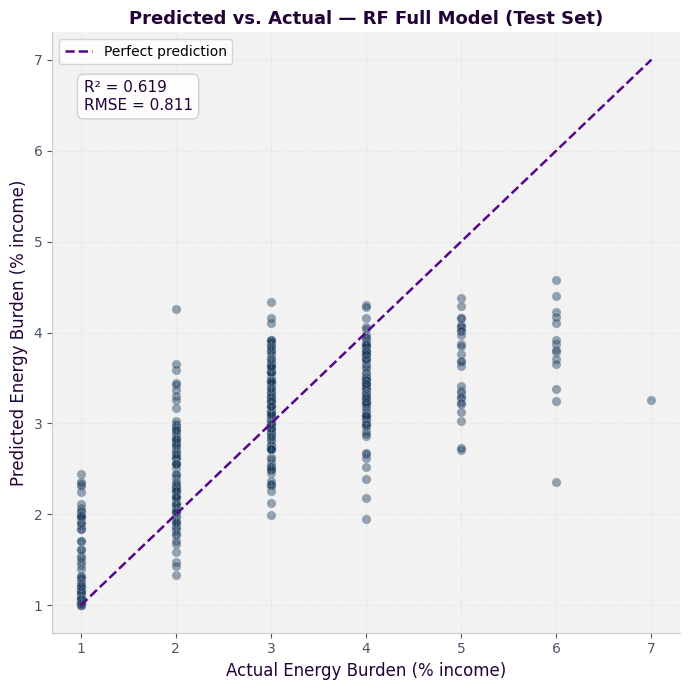

In [ ]:
# Step 11: Prediction Vs Actual FORMATTED FOR PRESENTATION
preds = rf_final_test.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

ax.scatter(y_test, preds, alpha=0.45, color='#1A3A5C',
           edgecolors='white', linewidths=0.3, s=45)

# prediction lin
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='#57068C', linewidth=1.8, linestyle='--', label='Perfect prediction')

# Annotation
from sklearn.metrics import r2_score, mean_squared_error
r2   = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
ax.text(0.05, 0.92, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}',
        transform=ax.transAxes, fontsize=11, color='#220337',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.9))

ax.set_xlabel('Actual Energy Burden (% income)', fontsize=12, color='#220337')
ax.set_ylabel('Predicted Energy Burden (% income)', fontsize=12, color='#220337')
ax.set_title('Predicted vs. Actual — RF Full Model (Test Set)',
             fontsize=13, fontweight='bold', color='#220337')
ax.legend(fontsize=10, framealpha=0.8, edgecolor='#CCCCCC')
ax.grid(alpha=0.25, linestyle='--', color='#CCCCCC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(colors='#4A5568')

plt.tight_layout()
plt.show()

Selected tracts for contribution analysis:
Label              Borough        Actual  Predicted
----------------------------------------------------
Low Burden (Manhattan) Manhattan       1.00%      1.91%
Typical Burden (Brooklyn) Brooklyn        3.00%      3.18%
High Burden (Bronx) Bronx           4.00%      3.85%

Baseline (global mean prediction): 2.780%


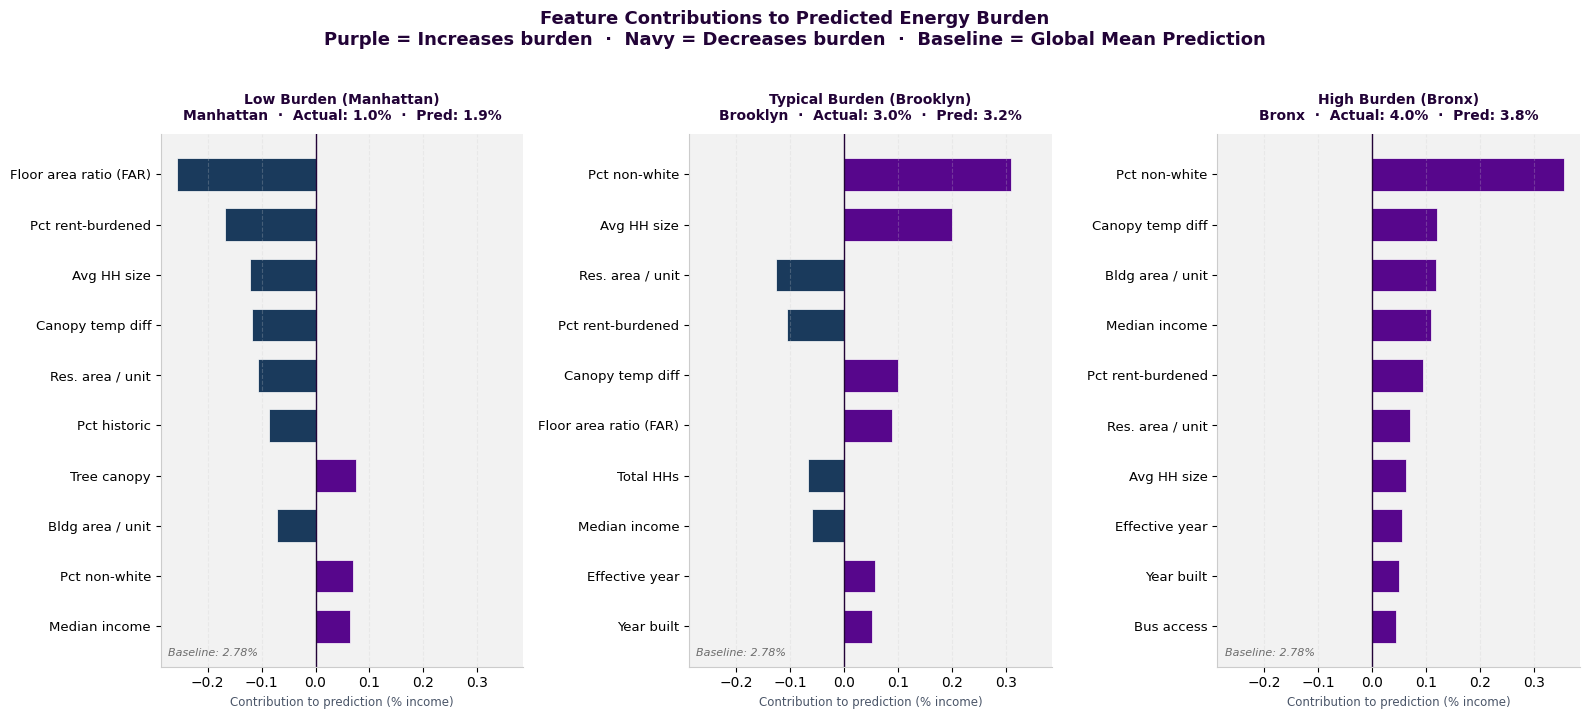

In [ ]:
# Step 12: Feature Contribution Analysis (Per-Tract Interpretability)
# Adapted from the treeinterpreter algorithm (Palczewska et al., 2014).
# For regression RF, any prediction can be decomposed as:
#   prediction = bias + sum(feature contributions)
# where bias = global mean prediction (root node average across all trees)
# and each contribution shows how much that feature pushed the prediction
# up (positive) or down (negative) from the baseline.

import numpy as np
import matplotlib.pyplot as plt

# 1. Manual feature contribution function

def forest_contributions(model, X_row):
    X_arr = np.array(X_row).reshape(1, -1)
    bias_total = 0.0
    contributions = np.zeros(X_arr.shape[1])

    for tree in model.estimators_:
        t = tree.tree_
        node_value = lambda n: t.value[n, 0, 0]

        node = 0
        path_nodes = [0]
        while t.feature[node] != -2:
            if X_arr[0, t.feature[node]] <= t.threshold[node]:
                node = t.children_left[node]
            else:
                node = t.children_right[node]
            path_nodes.append(node)

        for j in range(len(path_nodes) - 1):
            feat = t.feature[path_nodes[j]]
            contributions[feat] += node_value(path_nodes[j+1]) - node_value(path_nodes[j])

        bias_total += node_value(0)

    n_trees = len(model.estimators_)
    return bias_total / n_trees, contributions / n_trees


# 2. Pick 3 illustrative tracts from the test set
# 1 low-burden, typical, high-burden tract.

df_test = df.iloc[X_test.index].copy()
df_test['predicted'] = rf_final_test.predict(X_test)

#Make it so different categories come from different boroughs to reduce potential confusion and also matches general trends (census block WITHIN the borough though)
# Low burden tract where FAR is high but income is closer to city average(extreme wealth in certain tracks creates misleading graphic)
city_median_income = df_test['median_income'].median()

#force low to come from manhattan for interpretation purposes
low_candidates = df_test[
    (df_test['Energy Burden (% income)'] <= 1.5) &
    (df_test['Borough'] == 'Manhattan') &
    (df_test['pluto_mean_builtfar'] > df_test['pluto_mean_builtfar'].median()) &
    (df_test['median_income'] < city_median_income * 1.5)
]

low_idx = low_candidates.nsmallest(10, 'Energy Burden (% income)').iloc[3].name
mid_idx  = df_test[df_test['Borough'] == 'Brooklyn']\
               .assign(dist=lambda d: (d['Energy Burden (% income)'] - d['Energy Burden (% income)'].mean()).abs())\
               .nsmallest(5, 'dist').index[0]

# High burden Bronx tract close to high mean
bronx_high = df_test[df_test['Borough'] == 'Bronx'].copy()
bronx_high['pred_error'] = abs(bronx_high['predicted'] - bronx_high['Energy Burden (% income)'])

bronx_high_candidates = bronx_high[
    (bronx_high['Energy Burden (% income)'] >= 3.0) &
    (bronx_high['Energy Burden (% income)'] <= 5.0)   # realistic high, not outlier
]

high_idx = bronx_high_candidates.nsmallest(10, 'pred_error').iloc[0].name

picks = {
    'Low Burden (Manhattan)':  low_idx,
    'Typical Burden (Brooklyn)': mid_idx,
    'High Burden (Bronx)':     high_idx,
}

print("Selected tracts for contribution analysis:")
print(f"{'Label':<18} {'Borough':<12} {'Actual':>8} {'Predicted':>10}")
print("-" * 52)
for label, idx in picks.items():
    bor = df_test.loc[idx, 'Borough']
    act = df_test.loc[idx, 'Energy Burden (% income)']
    pre = df_test.loc[idx, 'predicted']
    print(f"{label:<18} {bor:<12} {act:>7.2f}%  {pre:>8.2f}%")


# 3. Readable feature names

name_map = {
    'pluto_mean_yearbuilt':     'Year built',
    'pluto_mean_effective_year':'Effective year',
    'pluto_mean_builtfar':      'Floor area ratio (FAR)',
    'pluto_bldgarea_per_unit':  'Bldg area / unit',
    'pluto_resarea_per_unit':   'Res. area / unit',
    'pluto_avg_lotarea':        'Avg lot area',
    'pluto_commercial_share':   'Commercial share',
    'pluto_pct_residential':    'Pct residential',
    'pluto_pct_historic':       'Pct historic',
    'pluto_pct_landmark':       'Pct landmark',
    'canopy_treecanopy':        'Tree canopy',
    'canopy_temp_diff':         'Canopy temp diff',
    'subway_05mi':              'Subway access',
    'bus_025mi':                'Bus access',
    'median_income':            'Median income',
    'pct_nonwhite':             'Pct non-white',
    'pct_renter':               'Pct renters',
    'avg_hh_size':              'Avg HH size',
    'pct_rent_burdened':        'Pct rent-burdened',
    'Total Households':         'Total HHs',
}
feat_display = [name_map[f] for f in feature_cols]


# 4. Compute contributions for each tract

results = {}
for label, idx in picks.items():
    row = X.loc[idx]
    bias, contribs = forest_contributions(rf_final_test, row)
    results[label] = {
        'bias':          bias,
        'contributions': contribs,
        'actual':        df_test.loc[idx, 'Energy Burden (% income)'],
        'predicted':     df_test.loc[idx, 'predicted'],
        'borough':       df_test.loc[idx, 'Borough'],
    }

print(f"\nBaseline (global mean prediction): {results['Low Burden (Manhattan)']['bias']:.3f}%")


# 5. Plot

C_up   = '#57068C'   # purple
C_down = '#1A3A5C'   # navy
C_text = '#220337'
C_grid = '#CCCCCC'
C_base = '#6D6D6D'

bg_cols = ['#F2F2F2', '#F2F2F2', '#F2F2F2']  # uniform light gray behind all panels

fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=False, sharex=True)
fig.patch.set_facecolor('white')

fig.suptitle(
    'Feature Contributions to Predicted Energy Burden\n'
    'Purple = Increases burden  ·  Navy = Decreases burden  ·  Baseline = Global Mean Prediction',
    fontsize=13, fontweight='bold', color=C_text, y=1.02
)

for i, (label, data) in enumerate(results.items()):
    ax = axes[i]
    ax.set_facecolor(bg_cols[i])

    contribs = data['contributions']
    order  = np.argsort(np.abs(contribs))[::-1][:10]
    top_c  = contribs[order][::-1]
    top_n  = [feat_display[o] for o in order][::-1]

    colors = ['#57068C' if c > 0 else '#1A3A5C' for c in top_c]
    ax.barh(range(len(top_n)), top_c, color=colors,
            edgecolor='white', linewidth=0.5, height=0.65)

    ax.axvline(0, color=C_text, linewidth=1.0)
    ax.set_yticks(range(len(top_n)))
    ax.set_yticklabels(top_n, fontsize=9.5)
    ax.set_xlabel('Contribution to prediction (% income)', fontsize=8.5, color='#4A5568')
    ax.grid(axis='x', alpha=0.25, linestyle='--', color=C_grid)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(C_grid)
    ax.spines['bottom'].set_color(C_grid)

    ax.set_title(
        f"{label}\n"
        f"{data['borough']}  ·  Actual: {data['actual']:.1f}%  ·  Pred: {data['predicted']:.1f}%",
        fontsize=10, fontweight='bold', color=C_text, pad=10
    )
    ax.text(0.02, 0.02, f"Baseline: {data['bias']:.2f}%",
            transform=ax.transAxes, fontsize=8, color=C_base, style='italic')

plt.tight_layout()
plt.savefig('feature_contributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

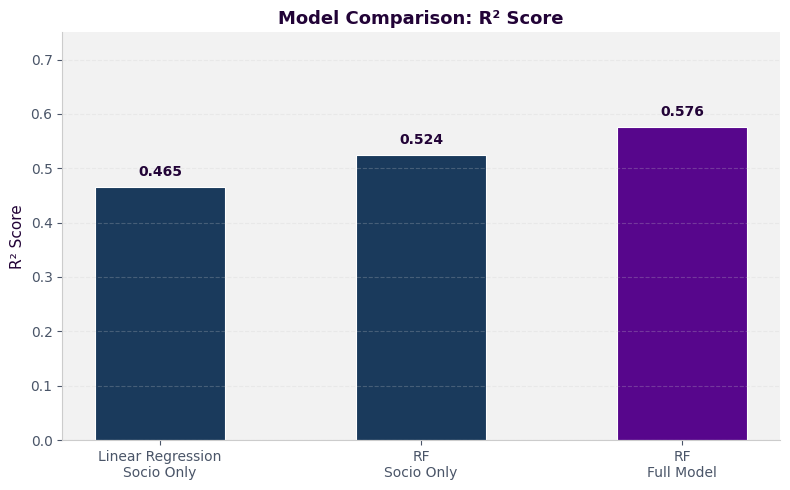

In [ ]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression\nSocio Only', 'RF\nSocio Only', 'RF\nFull Model'],
    'RMSE': [-rmse_lr.mean(), -rmse_ab.mean(), -rmse_rf.mean()],
    'R2': [r2_lr.mean(), r2_ab.mean(), r2_rf.mean()]
})

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

bars = ax.bar(
    model_results['Model'],
    model_results['R2'],
    color=['#1A3A5C', '#1A3A5C', '#57068C'],  # navy for baseline and purple for the full model
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

# R² values on top of each bar
for bar, val in zip(bars, model_results['R2']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#220337')

ax.set_ylabel('R² Score', fontsize=11, color='#220337')
ax.set_title('Model Comparison: R² Score', fontsize=13, fontweight='bold', color='#220337')
ax.set_ylim(0, 0.75)
ax.grid(axis='y', alpha=0.25, linestyle='--', color='#CCCCCC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(colors='#4A5568')

plt.tight_layout()
plt.show()